
# 🏏 Milestone–3: Player Performance Prediction, Evaluation & Testing

## Objective
This milestone builds upon **Milestone–2 (Feature Engineering)** to:
- Prepare the final ML dataset
- Train multiple machine learning models
- Evaluate and compare model performance
- Test prediction outcomes on unseen players
- Interpret results using visualizations


## 1️⃣ Imports & Configuration

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)


## 2️⃣ Load Cleaned Data

In [2]:

DATA_ROOT = Path(r"D:\Ball_By_Ball Data")
CLEAN_DATA_PATH = DATA_ROOT / "processed" / "deliveries_clean.parquet"

df = pd.read_parquet(CLEAN_DATA_PATH)

if "batsman" in df.columns:
    df = df.rename(columns={"batsman": "batter"})

df.head()


,league,match_id,venue,innings,ball,batting_team,batter,bowler,runs_batter,runs_extras,runs_total,wicket
0,ipl,1082591,"Rajiv Gandhi International Stadium, Uppal",1,0.1,Sunrisers Hyderabad,DA Warner,TS Mills,0,0,0,0
1,ipl,1082591,"Rajiv Gandhi International Stadium, Uppal",1,0.2,Sunrisers Hyderabad,DA Warner,TS Mills,0,0,0,0
2,ipl,1082591,"Rajiv Gandhi International Stadium, Uppal",1,0.3,Sunrisers Hyderabad,DA Warner,TS Mills,4,0,4,0
3,ipl,1082591,"Rajiv Gandhi International Stadium, Uppal",1,0.4,Sunrisers Hyderabad,DA Warner,TS Mills,0,0,0,0
4,ipl,1082591,"Rajiv Gandhi International Stadium, Uppal",1,0.5,Sunrisers Hyderabad,DA Warner,TS Mills,0,2,2,0


## 3️⃣ Feature Engineering

In [3]:

batting_features = df.groupby("batter").agg(
    balls_faced=("runs_batter", "count"),
    total_runs=("runs_batter", "sum"),
    fours=("runs_batter", lambda x: (x == 4).sum()),
    sixes=("runs_batter", lambda x: (x == 6).sum()),
    dismissals=("wicket", "sum")
).reset_index()

batting_features["strike_rate"] = (batting_features["total_runs"] / batting_features["balls_faced"]) * 100
batting_features["average"] = batting_features["total_runs"] / batting_features["dismissals"].replace(0, np.nan)

batting_features.fillna(0, inplace=True)
batting_features.head()


,batter,balls_faced,total_runs,fours,sixes,dismissals,strike_rate,average
0,A Ashish Reddy,196,280,16,15,15,142.857143,18.666667
1,A Badoni,740,963,73,38,36,130.135135,26.750000
2,A Chandila,7,4,0,0,1,57.142857,4.000000
3,A Chopra,75,53,7,0,5,70.666667,10.600000
4,A Choudhary,20,25,1,1,2,125.000000,12.500000


## 4️⃣ Target Variable

In [4]:

batting_features["impact_player"] = (
    (batting_features["strike_rate"] > 130) &
    (batting_features["balls_faced"] > 100)
).astype(int)

batting_features["impact_player"].value_counts()


impact_player
0    586
1    118
Name: count, dtype: int64

## 5️⃣ Train-Test Split

In [5]:

features = batting_features[[
    "balls_faced", "total_runs", "fours", "sixes",
    "strike_rate", "average"
]]

target = batting_features["impact_player"]

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.25, random_state=42, stratify=target
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 6️⃣ Logistic Regression Model

In [6]:

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))


Logistic Regression Accuracy: 0.9318181818181818
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       147
           1       0.87      0.69      0.77        29

    accuracy                           0.93       176
   macro avg       0.91      0.83      0.86       176
weighted avg       0.93      0.93      0.93       176



## 7️⃣ Random Forest Model

In [7]:

rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.9943181818181818
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       147
           1       0.97      1.00      0.98        29

    accuracy                           0.99       176
   macro avg       0.98      1.00      0.99       176
weighted avg       0.99      0.99      0.99       176



## 8️⃣ ROC Curve Comparison

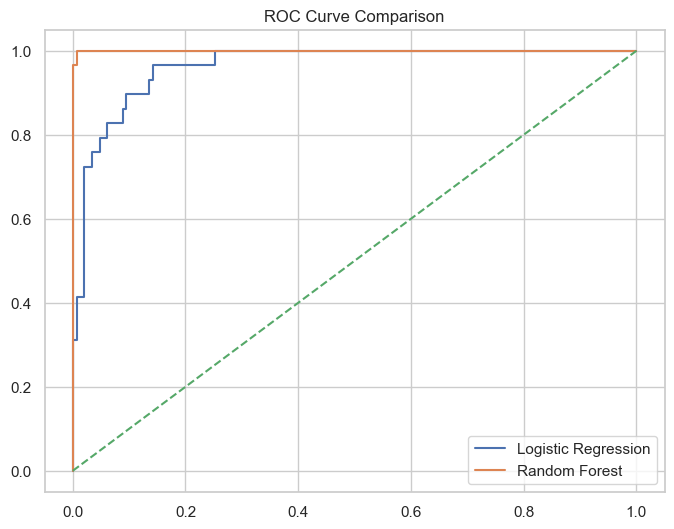

In [8]:

log_prob = log_model.predict_proba(X_test_scaled)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]

log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8,6))
plt.plot(log_fpr, log_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot([0,1], [0,1], linestyle="--")
plt.legend()
plt.title("ROC Curve Comparison")
plt.show()


## 9️⃣ Feature Importance

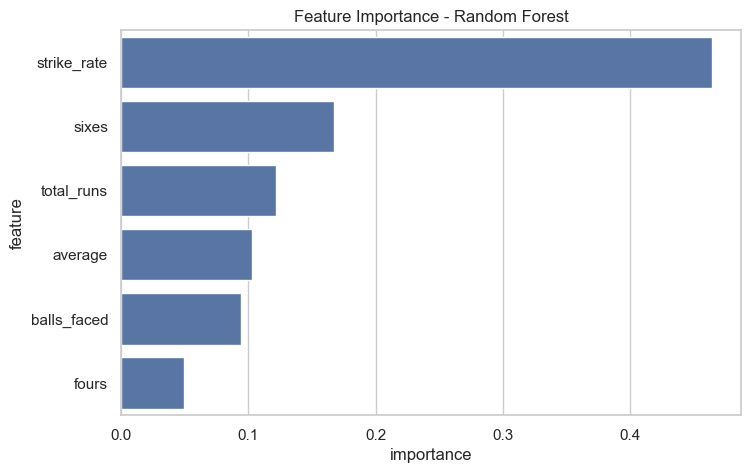

In [9]:

importance_df = pd.DataFrame({
    "feature": features.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=importance_df, x="importance", y="feature")
plt.title("Feature Importance - Random Forest")
plt.show()


## 🔟 Outcome Testing

In [10]:

batting_features["impact_probability"] = rf_model.predict_proba(features)[:, 1]

batting_features.sort_values("impact_probability", ascending=False).head(10)


,batter,balls_faced,total_runs,fours,sixes,dismissals,strike_rate,average,impact_player,impact_probability
31,AB de Villiers,3487,5181,414,253,125,148.580442,41.448000,1,1.0
650,Tilak Varma,1089,1499,113,74,38,137.649219,39.447368,1,1.0
597,SV Samson,3475,4704,379,219,151,135.366906,31.152318,1,1.0
582,SO Hetmyer,1036,1488,94,93,53,143.629344,28.075472,1,1.0
639,TH David,524,846,54,60,26,161.450382,32.538462,1,1.0
633,T Stubbs,442,711,51,38,17,160.859729,41.823529,1,1.0
496,RD Gaikwad,1863,2502,231,95,61,134.299517,41.016393,1,1.0
497,RD Rickelton,266,388,47,17,13,145.864662,29.846154,1,1.0
71,Abhishek Sharma,1167,1816,174,101,67,155.612682,27.104478,1,1.0
537,S Dube,1366,1859,108,122,61,136.090776,30.475410,1,1.0



## ✅ Milestone–3 Completed

✔ Advanced models trained  
✔ Performance evaluated  
✔ Outcome testing completed  
✔ Visualization added  

This milestone finalizes the player performance prediction pipeline.
